# TREAT-MMTB 2026 Task2 : TB Classification Baseline(26.05.22v)

## Directory Structure
```
Task2/
├── Data/
│   ├── train/                     #  train images (.png)
│   ├── test/                      #  test images (.png)
│   └── train.csv                  # TB/Normal, new_id, age, gender, Modality
│
├── Code/
│   └── task2_explain_baseline.ipynb     # This notebook
│
└── info.txt                       # Project description
```

**Note:** 
-  Paths in this notebook are examples. Adjust to your environment as needed.
-  This notebook is provided as a reference with pre-executed outputs.
-  Dataset access will be granted only to registered participants.

## 0. Preprocessing

All images are pre-resized to 512x512.


| Channel | Suffix | Method |
|---------|--------|--------|
| Ch0 | `_0000` | Mean-Std Normalization |
| Ch1 | `_0001` | Mean-Std Normalization → CLAHE|
| Ch2 | `_0002` | Duplicate of Ch0 (to match 3-channel input required by the model) |



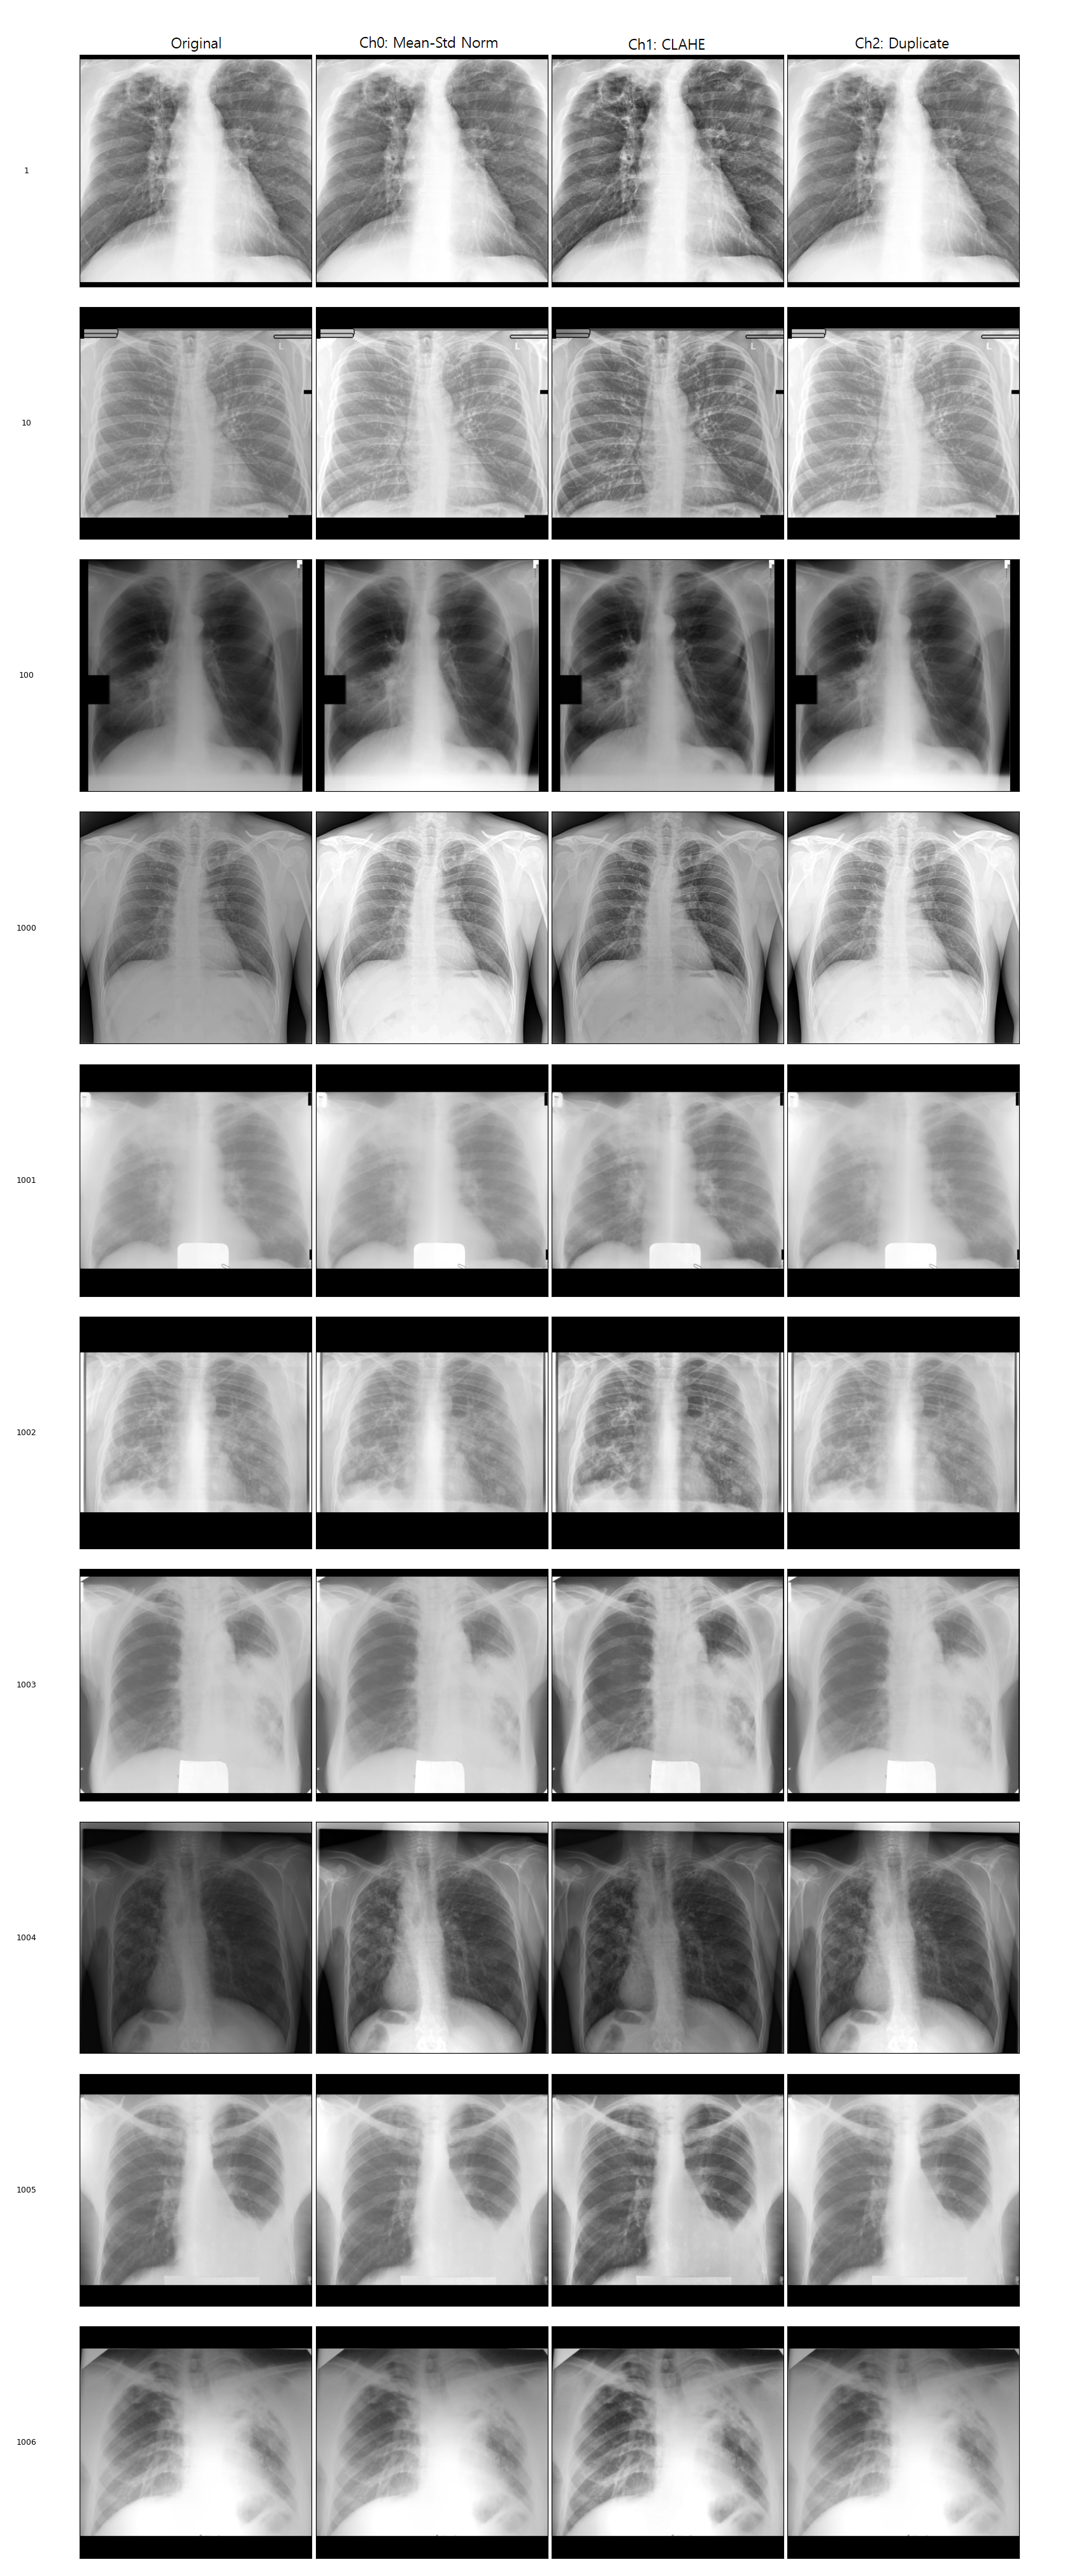

In [ ]:
import os
import glob
import cv2
import numpy as np
from tqdm.auto import tqdm

### You may use just one preprocessed channel, or all three of them

# data path
DIR_IN_IMG = 'SELECT_YOUR_DATA_DIR_PATH'         # e.g. /data/Task2/Data/train

# result path
DIR_OUT_BASE = 'SELECT_YOUR_OUTPUT_DIR_PATH'      # e.g. /workspace/Task2/Preprocessed/train_images
DIR_OUT_CH0 = os.path.join(DIR_OUT_BASE, 'ch0')
DIR_OUT_CH1 = os.path.join(DIR_OUT_BASE, 'ch1')
DIR_OUT_CH2 = os.path.join(DIR_OUT_BASE, 'ch2')

for p in [DIR_OUT_CH0, DIR_OUT_CH1, DIR_OUT_CH2]:
    os.makedirs(p, exist_ok=True)

def rescale_to_01(data, robust=True, lower=0.5, upper=99.5):
    data = np.asarray(data).astype(np.float32)

    if not np.isfinite(data).all():
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if robust:
        lo = np.percentile(data, lower)
        hi = np.percentile(data, upper)
    else:
        lo = np.min(data)
        hi = np.max(data)

    if hi <= lo + 1e-8:
        return np.zeros_like(data, dtype=np.float32)

    data = np.clip(data, lo, hi)
    data = (data - lo) / (hi - lo + 1e-8)
    return data.astype(np.float32)


def save_with_cv2(data, save_path):
    """Save as uint8 .png (clipped to [0, 1] then scaled to [0, 255])."""
    data = np.asarray(data)
    out = np.clip(data, 0.0, 1.0)
    out = (out * 255.0 + 0.5).astype(np.uint8)
    cv2.imwrite(save_path, out)


# main loop
png_files = sorted(glob.glob(os.path.join(DIR_IN_IMG, "*.png")))
print(f"Start preprocessing images and masks n = {len(png_files)}")

for png_path in tqdm(png_files, desc="Preprocessing"):
    filename = os.path.basename(png_path)
    new_id = os.path.splitext(filename)[0]
    # print(new_id)
        
    try:
        # png preprocessing
        img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
        raw_pixels = img.astype(np.float32)
            
        # Mean-Std normalization
        base_norm = (raw_pixels - np.mean(raw_pixels)) / (np.std(raw_pixels) + 1e-8)
        
        # Channel 0
        ch0 = rescale_to_01(base_norm, robust=True)

        # Channel 1
        ch1_uint8 = (base_norm * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
        ch1 = clahe.apply(ch1_uint8).astype(np.float32) / 255.0

        # Channel 2
        ch2 = ch0.copy()


        #save
        save_with_cv2(ch0, os.path.join(train_out_img_path_ch0, f"{new_id}_0000.png"))
        save_with_cv2(ch1, os.path.join(train_out_img_path_ch1, f"{new_id}_0001.png"))
        save_with_cv2(ch2, os.path.join(train_out_img_path_ch2, f"{new_id}_0002.png"))

    except Exception as e:
        print(f"ID {new_id} error: {e}")

print(f"Results saved at {train_out_img_path}")
print(len(png_files))

## 1. Dataset Class

Define the custom PyTorch Dataset for loading preprocessed chest X-ray images with TB/Normal labels.

- Images are loaded as 3-channel RGB (required by ImageNet-pretrained ResNet50).
- Labels are mapped as: `Normal → 0`, `TB → 1`.
- The channel suffix (`_0000`, `_0001`, `_0002`) is automatically determined based on the selected preprocessing type (`ch0`, `ch1`, or `ch2`).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
import sys, os
from sklearn.model_selection import train_test_split
import time


class TBNormalDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        img_dir: str | Path,
        transform=None,
        image_col: str = "png_path",
        label_col: str = "TB/Normal",
    ):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = Path(img_dir)
        self.img_dir_marker = self.img_dir.name
        if self.img_dir_marker == "ch0":
            print("Preprocessed as mean-std normalization")
        elif self.img_dir_marker == "ch1":
            print("Preprocessed as CLAHE")
        elif self.img_dir_marker == "ch2":
            print("Preprocessed as duplicate")
        self.transform = transform
        self.image_col = image_col
        self.label_col = label_col

        self.label_map = {
            "normal": 0,
            "tb": 1,
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.img_dir_marker == "ch0":
            suffix = "_0000"
        elif self.img_dir_marker == "ch1":
            suffix = "_0001"
        elif self.img_dir_marker == "ch2":
            suffix = "_0002"
        row = self.df.iloc[idx]
        img_file = str(row["new_id"]) + suffix + ".png"
        img_path = self.img_dir / img_file

        # ResNet50 pretrained expects 3-channel RGB as input, so no
        image = Image.open(img_path).convert("RGB")

        label_str = str(row[self.label_col]).strip().lower()

        label = self.label_map[label_str]

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

## 2. Dataset & Dataloader

Configure the training pipeline:

- **Preprocessing type:** `ch2` (Duplicate of Mean-Std normalized channel). You can change this to `ch0` or `ch1` to experiment with different preprocessing.

In [ ]:
NUM_CLASSES = 2
random_seed = 42

preprocess_type = "ch0"

X_path = Path(f"SELECT_YOUR_DATA_DIR_PATH")
y_path = Path(f"SELECT_YOUR_CSV_DIR_PATH)

torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 1. Read csv
df = pd.read_csv(y_path)


# 2. train/validation split from train dataset
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=random_seed,
    stratify=df["TB/Normal"],
)

# 3. torch Dataset generation for train/validation
train_dataset = TBNormalDataset(
    df=train_df,
    img_dir=X_path,
    transform=transform,
)

val_dataset = TBNormalDataset(
    df=val_df,
    img_dir=X_path,
    transform=transform,
)


# 4. torch DataLoader generation for train/validation
train_loader = DataLoader(
    train_dataset,
    batch_size=48,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

# 5. check
train_N = len(train_dataset)
val_N = len(val_dataset)
print(f"Train samples: {train_N}, Val samples: {val_N}")
images, labels = next(iter(train_loader))
print(images.shape)  # torch.Size([B, 3, 224, 224])
print(labels.shape)  # torch.Size([B])
print(labels[:10])

## 3. Define model, loss function, optimizer

In [ ]:
# Define the model (using resnet50 pretrained on ImageNet-1k dataset)
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Replace the last layer (for finetune)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Move the model to the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the number of epochs
num_epochs = 10

# Train the model
for epoch in range(num_epochs):
    time0 = time.time()
    # Train the model on the training set
    model.train()
    train_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Move the data to the device
        inputs:torch.Tensor = inputs.to(device, non_blocking=True)
        labels:torch.Tensor = labels.to(device, non_blocking=True)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update the training loss
        train_loss += loss.item() * inputs.size(0)

    # Evaluate the model on the validation set
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_loader):
            # Move the data to the device
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Update the validation loss and accuracy
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_acc += torch.sum(preds == labels.data)

    # Print the training and validation loss and accuracy
    train_loss /= train_N
    val_loss /= val_N
    val_acc = val_acc.double() / val_N
    time1 = time.time()
    print(f"Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}, Elapsed Time: {time1 - time0:.2f} seconds")

## 4. Save Model weight

Save the trained model weights to `model_weight/` directory. The filename includes the preprocessing type (e.g., `ch3_resnet50.pth`) for easy identification.



In [ ]:
save_path = Path(f"SELECT_YOUR_SAVE_DIR_PATH")
save_path.mkdir(parents=True, exist_ok=True)
model_path = save_path / f"{preprocess_type}_resnet50.pth"
torch.save(model.state_dict(), model_path)
print(f"{preprocess_type}_resnet50 weight saved.")

## 5. Grad-CAM

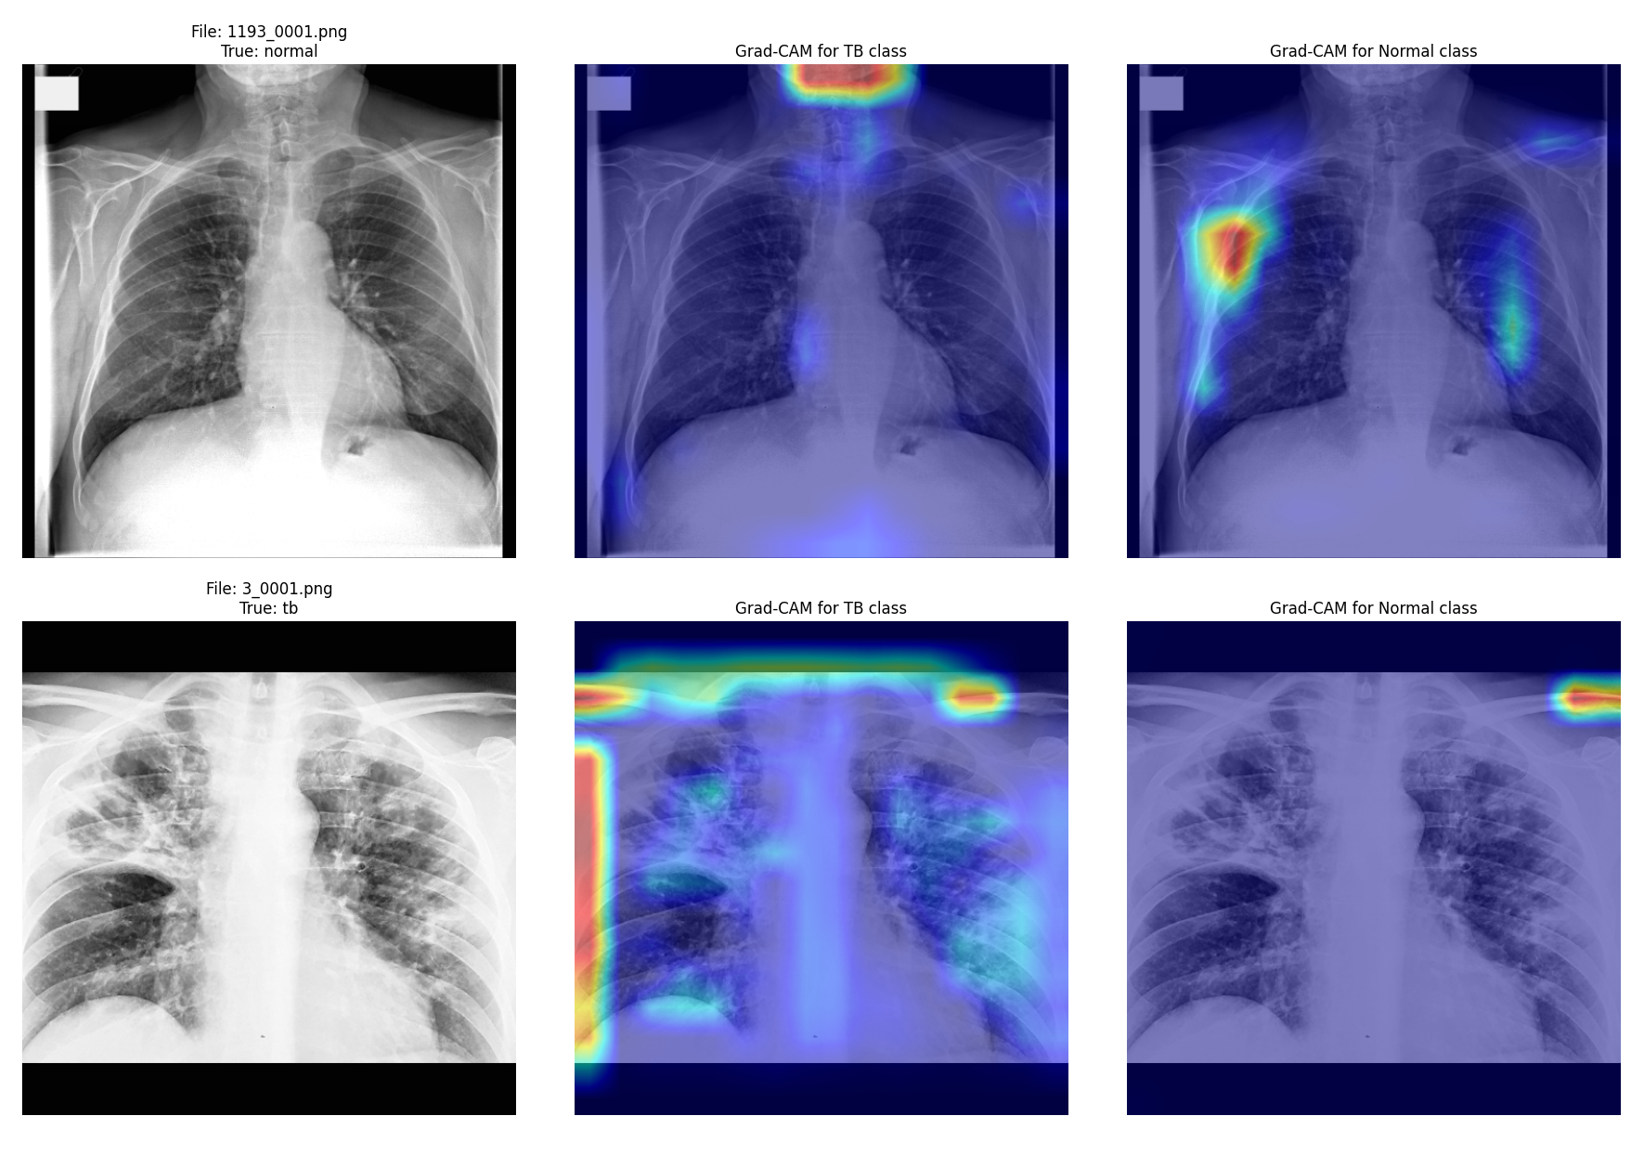

--- 
## 6. Baseline Performance (ResNet50)

| Metric | Score |
|--------|-------|
| Val Accuracy | 0.9955 |

Good luck, and we look forward to seeing your results!

## Notes

- This baseline uses a single preprocessing channel (`ch0`). You can train separate models on `ch1` (CLAHE) or `ch2` (Ch0 duplicate) by changing the `preprocess_type` variable.
- `train.csv` contains metadata columns: `TB/Normal`, `new_id`, `age`, `gender`, and `Modality`. Participants are encouraged to leverage these clinical variables for multimodal approaches.
- **Limitation of the Current Baseline (Domain Shift):** The current baseline merges two distinct datasets, resulting in a significant domain shift. As shown in the Grad-CAM results, the model currently tends to focus on superficial differences such as image size, resolution, and modality, rather than clinically meaningful areas like the lungs or specific anatomical structures.
- **External Validation Challenge:** Please note that the external datasets will be significantly different from the internal ones, featuring data from multiple countries across various modalities. It is crucial to develop robust models capable of overcoming this domain shift and focusing on true clinical features.
- **Upcoming Update:** We are also planning to release an updated baseline to address this issue soon.
- All participants are required to submit a short method paper (approx. 4 pages) describing their approach at the end of the internal competition phase.